# Examen ML for CyberSecurity - Ranime Jemal

## Partie I : Exploration des données

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [30]:
import pandas as pd

url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt"

df = pd.read_csv(url, header=None)

print("Dataset chargé avec succès")
df.head()

Dataset chargé avec succès


,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [36]:
# Assign column names to the DataFrame
column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land',
    'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'class', 'difficulty_level'
]
df.columns = column_names

print("Colonnes du dataset après renommage :")
print(df.columns.tolist())

display(df.head())

Colonnes du dataset après renommage :
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'class', 'difficulty_level']


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [37]:
# =========================
# DETECTION COLONNE LABEL
# =========================

# Possible names for the label column
possible_labels = [
    "Label",
    "label",
    "Class",
    "class", # 'class' is the correct label name after renaming
    "Attack",
    "attack",
    "Target",
    "target"
]

label_column = None

for col in possible_labels:
    if col in df.columns:
        label_column = col
        break

# Error if no label column is found
if label_column is None:
    raise Exception(
        f"Aucune colonne label trouvée. Colonnes disponibles : {df.columns.tolist()}"
    )

print(f"Colonne cible détectée : {label_column}")

# Remove the difficulty_level column as it's not a feature for classification
if 'difficulty_level' in df.columns and label_column != 'difficulty_level':
    print("Suppression de la colonne 'difficulty_level'.")
    df = df.drop(columns=['difficulty_level'])

Colonne cible détectée : class
Suppression de la colonne 'difficulty_level'.


In [6]:

# Afficher les dimensions
print("Dimensions du dataset :", df.shape)


Dimensions du dataset : (125972, 43)


In [7]:
print("\nDimensions du dataset :")
print(df.shape)


Dimensions du dataset :
(125972, 43)


In [8]:

# Types des variables
df.dtypes


,0
0,int64
tcp,object
ftp_data,object
SF,object
491,int64
0.1,int64
0.2,int64
0.3,int64
0.4,int64
0.5,int64


In [9]:

# Description statistique
df.describe()


,0,491,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,25,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,20
count,125972.000000,1.259720e+05,1.259720e+05,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,...,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000
mean,287.146929,4.556710e+04,1.977927e+04,0.000198,0.022688,0.000111,0.204411,0.001222,0.395739,0.279253,...,115.653725,0.521244,0.082952,0.148379,0.032543,0.284455,0.278487,0.118832,0.120241,19.504056
std,2604.525522,5.870354e+06,4.021285e+06,0.014086,0.253531,0.014366,2.149977,0.045239,0.489011,23.942137,...,110.702886,0.448950,0.188922,0.308998,0.112564,0.444785,0.445670,0.306559,0.319460,2.291512
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.000000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


class
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


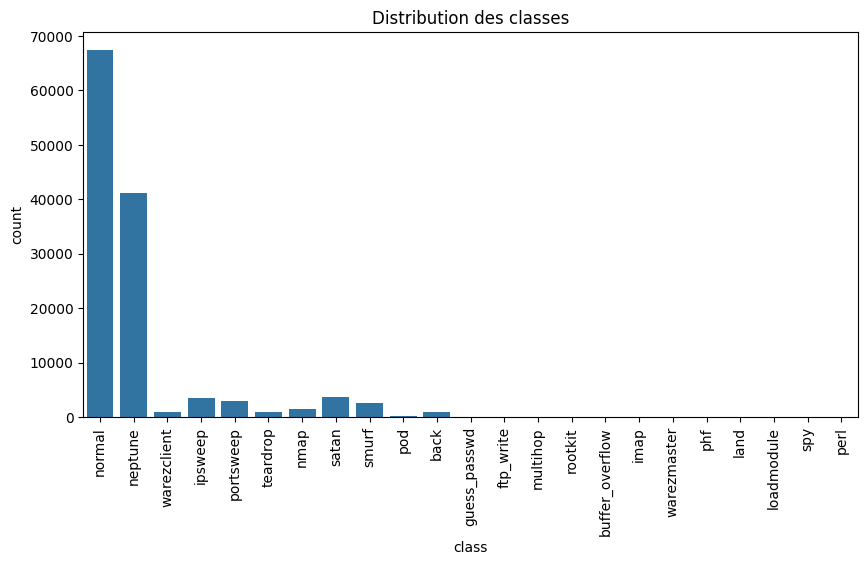

In [38]:

# Distribution des classes
print(df[label_column].value_counts())

plt.figure(figsize=(10,5))
sns.countplot(x=df[label_column])
plt.xticks(rotation=90)
plt.title("Distribution des classes")
plt.show()

In [13]:

# Valeurs manquantes et nulles
print("Valeurs manquantes :")
print(df.isnull().sum())

print("\nTotal des valeurs nulles :", df.isnull().sum().sum())


Valeurs manquantes :
0           0
tcp         0
ftp_data    0
SF          0
491         0
0.1         0
0.2         0
0.3         0
0.4         0
0.5         0
0.6         0
0.7         0
0.8         0
0.9         0
0.10        0
0.11        0
0.12        0
0.13        0
0.14        0
0.15        0
0.16        0
0.18        0
2           0
2.1         0
0.00        0
0.00.1      0
0.00.2      0
0.00.3      0
1.00        0
0.00.4      0
0.00.5      0
150         0
25          0
0.17        0
0.03        0
0.17.1      0
0.00.6      0
0.00.7      0
0.00.8      0
0.05        0
0.00.9      0
normal      0
20          0
dtype: int64

Total des valeurs nulles : 0


In [14]:

# Doublons
print("Nombre de doublons :", df.duplicated().sum())


Nombre de doublons : 0


## Partie II : Prétraitement

In [15]:

# Nettoyage des données
df = df.drop_duplicates()
df = df.dropna()

print("Nouvelle dimension :", df.shape)


Nouvelle dimension : (125972, 43)


In [39]:

# Encodage du label
encoder = LabelEncoder()
df[label_column] = encoder.fit_transform(df[label_column])

print(df[label_column].head())

0    11
1    11
2     9
3    11
4    11
Name: class, dtype: int64


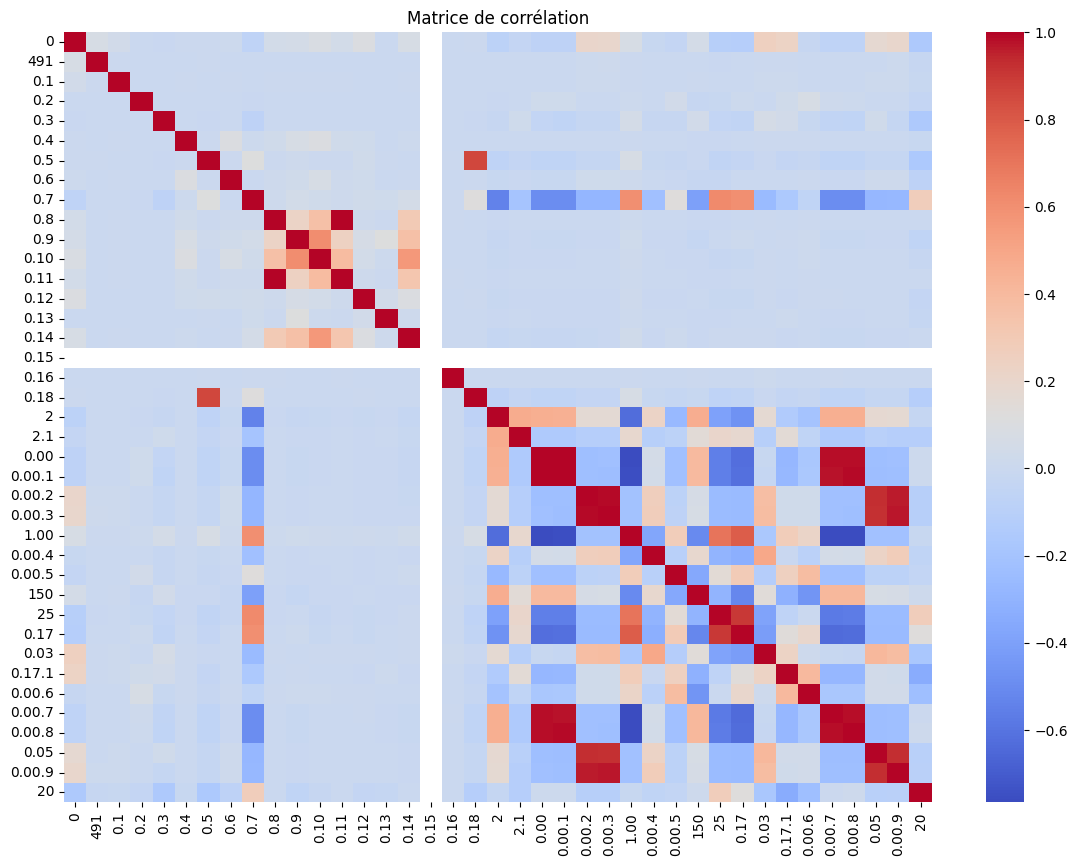

In [17]:

# Analyse de corrélation
plt.figure(figsize=(14,10))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()


In [18]:

# Suppression des variables fortement corrélées

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print("Colonnes supprimées :", to_drop)

df = df.drop(columns=to_drop)


Colonnes supprimées : ['0.11', '0.00.1', '0.00.3', '0.00.7', '0.00.8', '0.00.9']


In [33]:

# Détection des outliers avec IQR

# Select only numeric columns for outlier detection
numeric_df = df.select_dtypes(include=np.number)

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).sum()

print("Nombre d'outliers par colonne :")
print(outliers)

Nombre d'outliers par colonne :
0     10018
4     13840
5     23579
6        25
7      1090
8         9
9      2671
10      122
11        0
12     1286
13      169
14       80
15      649
16      287
17       47
18      371
19        0
20        1
21     1187
22     3157
23    12054
24        0
25        0
26    16190
27    16206
28        0
29     7788
30    28399
31        0
32        0
33        0
34    10550
35    25052
36    11682
37        0
38        0
39    22795
40    19357
42     2995
dtype: int64


In [40]:

# Séparation X et y

# X and y are already defined in the label detection cell
# This cell is now redundant if the previous cells are run correctly
# However, to be safe, we will re-define them here using the determined label_column
y = df[label_column]
X = df.drop(label_column, axis=1)


In [44]:
# Normalisation des données

# Identify categorical columns in X
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# Apply one-hot encoding to categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("Shape of X after encoding and scaling:", X_scaled.shape)

Shape of X after encoding and scaling: (125973, 119)


In [45]:

# Split train/test

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)


Train : (100778, 119)
Test : (25195, 119)


## Partie III : Modélisation


# 1. Clustering - KMeans

Le clustering K-Means permet de regrouper les flux réseau similaires.
L'inertie mesure la distance des points à leur centre de cluster.


In [46]:

# Application K-Means

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

clusters = kmeans.labels_

print("Clusters générés :", np.unique(clusters))


Clusters générés : [0 1]


In [47]:

# Calcul de l'inertie

print("Inertie :", kmeans.inertia_)


Inertie : 14738730.401278993


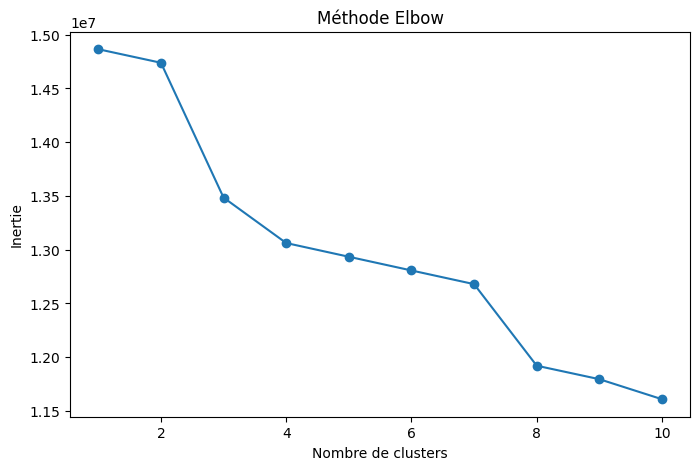

In [48]:

# Méthode Elbow

inertias = []

K = range(1,11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertias, marker='o')
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.title("Méthode Elbow")
plt.show()



# 2. Classification avec SVM

Le SVM cherche un hyperplan optimal maximisant la marge entre les classes.
Une grande marge améliore la généralisation du modèle.


In [49]:

# SVM kernel linéaire

svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

acc_linear = accuracy_score(y_test, y_pred_linear)

print("Accuracy SVM Linéaire :", acc_linear)


Accuracy SVM Linéaire : 0.992577892438976


In [50]:

# SVM kernel RBF

svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

acc_rbf = accuracy_score(y_test, y_pred_rbf)

print("Accuracy SVM RBF :", acc_rbf)


Accuracy SVM RBF : 0.9879341139114903



Comparaison :
- Le kernel linéaire est plus rapide.
- Le kernel RBF capture mieux les relations non linéaires.



# 3. Classification avec ANN

Structure ANN :
- Input Layer : reçoit les caractéristiques
- Hidden Layers : apprennent les relations complexes
- Output Layer : prédit la classe finale


In [53]:

# Implémentation ANN (MLP)

ann = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=200
)


In [54]:

# Entraînement ANN

ann = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=200,
    random_state=42
)

ann.fit(X_train, y_train)

y_pred_ann = ann.predict(X_test)

acc_ann = accuracy_score(y_test, y_pred_ann)

print("Accuracy ANN :", acc_ann)


Accuracy ANN : 0.9952768406429847


In [55]:

# Ajustement hyperparamètres

ann2 = MLPClassifier(
    hidden_layer_sizes=(128,64),
    max_iter=300,
    random_state=42
)

ann2.fit(X_train, y_train)

y_pred_ann2 = ann2.predict(X_test)

acc_ann2 = accuracy_score(y_test, y_pred_ann2)

print("Accuracy ANN optimisé :", acc_ann2)


Accuracy ANN optimisé : 0.9957134352053979


## 4. Régression Linéaire

In [58]:

# Définir X et y pour la régression

target = 'src_bytes' # Changed target to 'src_bytes'

X_reg = df.drop(columns=[target])
y_reg = df[target]

# Garder uniquement les colonnes numériques
X_reg = X_reg.select_dtypes(include=np.number)

# Normalisation
X_reg_scaled = scaler.fit_transform(X_reg)

# Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_scaled,
    y_reg,
    test_size=0.2,
    random_state=42
)


In [59]:

# Entraîner le modèle

lr = LinearRegression()

lr.fit(X_train_reg, y_train_reg)

y_pred_reg = lr.predict(X_test_reg)


In [60]:

# Évaluation

mse = mean_squared_error(y_test_reg, y_pred_reg)

rmse = np.sqrt(mse)

r2 = r2_score(y_test_reg, y_pred_reg)

print("MSE :", mse)
print("RMSE :", rmse)
print("R² :", r2)


MSE : 15537480959827.412
RMSE : 3941761.1495152027
R² : 0.011574813121307925



## Partie IV : Évaluation et Interprétation

### Comparaison des modèles
- KMeans : utile pour détecter des comportements inconnus
- SVM : très performant pour classification supervisée
- ANN : apprend des relations complexes mais coûteux en calcul
- Régression : utile pour prédire des métriques réseau

### Meilleur modèle classification
Le meilleur modèle est généralement ANN ou SVM RBF selon accuracy.

### Meilleur modèle prédiction
La régression linéaire est évaluée avec :
- MSE
- RMSE
- R²

### Interprétation cybersécurité
- SVM : robuste pour attaques connues
- ANN : efficace mais plus lourd en calcul
- KMeans : utile pour détecter des attaques inconnues/anomalies
- Régression : aide à prévoir le trafic réseau anormal
